### Import Libraries

In [1]:
import os
import cv2 as cv
import pafy
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

#from moviepy.editor import *
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

2025-10-21 01:03:34.642486: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Reduce GPU Memory Usage
✅ Enable Memory Growth for TensorFlow

In [2]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
print("Available GPUs:", gpu_devices)

# Enable memory growth before TensorFlow initializes the GPU
if gpu_devices:
    try:
        for device in gpu_devices:
            tf.config.experimental.set_memory_growth(device, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print("Failed to set memory growth:", e)

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled for GPUs.


### Set Numpy, Python and Tensorflow seeds to get consistent results on every execution.

In [3]:
seed_constant = 27
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

For visualization, we will pick 20 random categories from the dataset and a random video from each selected category and will visualize the first frame of the selected videos with their associated labels written. This way we'll be able to visualize a subset of the datset.

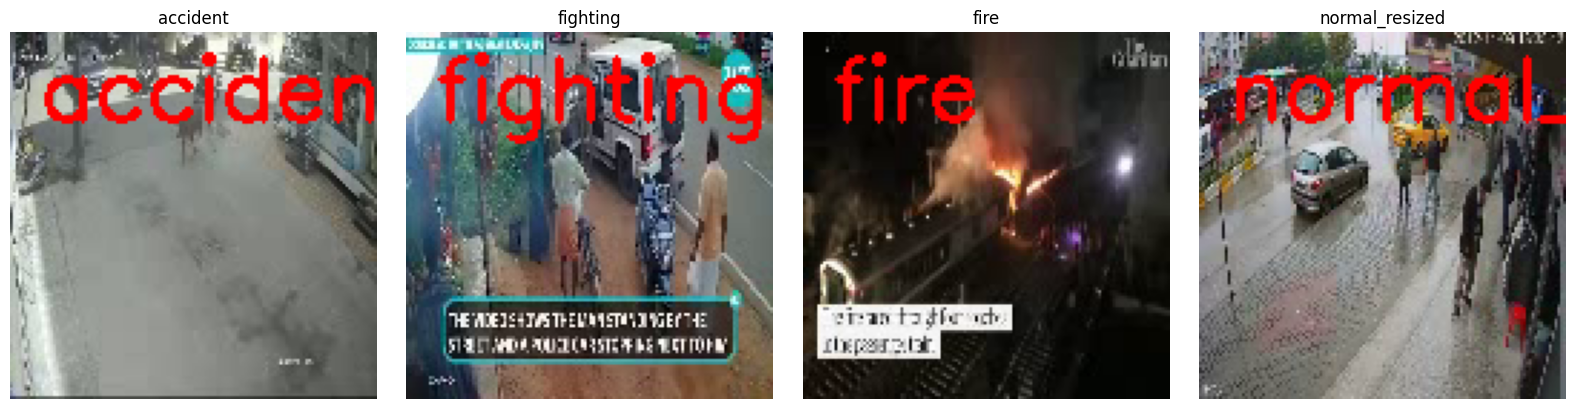

In [4]:
ds_name = 'multi_class__short_ds_resized_128'

# Get the names of all classes/categories in the dataset
all_classes_names = os.listdir(ds_name)
num_classes = len(all_classes_names)
    
# Determine the number of rows and columns for the subplot
cols = min(num_classes, 5)  # Limit columns to 5 for better visualization
rows = (num_classes // cols) + (num_classes % cols > 0)
    
# Create a Matplotlib figure with an appropriate size
plt.figure(figsize=(cols * 4, rows * 4))
    
# Iterate through all classes
for counter, selected_class_name in enumerate(all_classes_names, 1):
    # Retrieve the list of all video files in the selected class directory
    video_files_names_list = os.listdir(f'{ds_name}/{selected_class_name}')
        
    if not video_files_names_list:
        continue  # Skip if the class folder is empty
        
    # Randomly select a video file from the list
    selected_video_file_name = random.choice(video_files_names_list)
        
    # Initialize a VideoCapture object to read from the video file
    video_reader = cv.VideoCapture(f'{ds_name}/{selected_class_name}/{selected_video_file_name}')
        
    # Read the first frame of the video file
    success, bgr_frame = video_reader.read()
        
    # Release the VideoCapture object
    video_reader.release()
        
    if not success:
        continue  # Skip if the frame could not be read
            
    # Convert the frame from BGR to RGB format
    rgb_frame = cv.cvtColor(bgr_frame, cv.COLOR_BGR2RGB)
            
    # Write the class name on the video frame
    cv.putText(rgb_frame, selected_class_name, (10, 30), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
            
    # Display the frame
    plt.subplot(rows, cols, counter)
    plt.imshow(rgb_frame)
    plt.axis('off')
    plt.title(selected_class_name)

plt.tight_layout()
plt.show()

### Step 2: Preprocess the Dataset

Next, we will perform some preprocessing on the dataset. First, we will read the video files from the dataset and resize the frames of the videos to a fixed width and height, to reduce the computations and normalized the data to range [0 - 1] by dividing the pixel values with 255, which makes convergence faster while training the network.

But first, Initializing some constants.

In [5]:
# Specify the height and width to which each video frame will be resized in our dataset.
IMAGE_HEIGHT , IMAGE_WIDTH = 128, 128

# Specify the number of frames of a video that will be fed to the model as one sequence.
SEQUENCE_LENGTH = 7

# Specify the directory containing the UCF50 Dataset.
DATASET_DIR = "multiclass_with_ucf_128"

# Specify the list containing the names of the classes used for training.
CLASSES_LIST = ["accident", "fighting", "fire", "normal_resized"]
#CLASSES_LIST = ["Abnormal", "Normal"]

**Note:** *The IMAGE_HEIGHT, IMAGE_WIDTH and SQUENCE_LENGTH constants can be increased for better results, although increasing the sequence.*

### Create a Function to Extract, Resize & Normalize Frames

We will create a function **`frames_extraction()`** that will create a list containing the resized and normalized frames of a video whose path is passed to it as an argument. The function will read the video file frame by frame, although not all frames are added to the list as we will only need an evenly distributed sequence length of frames.

In [6]:
def frames_extraction(video_path):
  '''
  This function will extract the required frames from a video after resizing and normalizing them.
  Args:
    video_path: The path of the video in the disk, whose frames are to be extracted.
  Returns:
    frames_list: A list containing the resized and normalized frames of the video.
  '''

  # Declare a list to store video frames.
  frames_list = []

  # Read the video File using the VideoCapture object.
  video_reader = cv.VideoCapture(video_path)

  # Get The total number of frames in the video
  video_frames_count = int(video_reader.get(cv.CAP_PROP_FRAME_COUNT))

  # Calculate the interval after which frames will be added to the list.
  skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH), 1)

  # Iterate through the Video Frames.
  for frame_counter in range(SEQUENCE_LENGTH):

    # Set the current frame position of the video.
    video_reader.set(cv.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

    # Reading the frame from the video.
    success, frame = video_reader.read()

    # Check if video frame is not successfully read then break the loop
    if not success:
      break

    # Resize the frame to fixed height and width.
    resized_frame = cv.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

    # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1
    normalized_frame = resized_frame / 255

    # Append the normalized frame into the frames list
    frames_list.append(normalized_frame)

  # Release the VideoCapture object.
  video_reader.release()

  # Return the frames list.
  return frames_list


### Create a Function for Dataset Creation

Now we will create a function **`create_dataset()`** that will iterate through all classes specified in the **`CLASSES_LIST`** constant and will call the function **`frame_extraction()`** on every video file of the selected classes and return the frames (**`features`**), class index(**`labels`**), and video file path (**`video_files_paths`**).

In [7]:
def create_dataset():
  '''
  This function will extract the data of the selected classes and create the required dataset.

  Returns:

    features:             A List containing the extracted frames of the videos.
    labels:               A list containing the indexes of the classes associated with the videos.
    video_files_paths:    A list containing the paths of the videos in the disk.

  '''


  # Declare Empty Lists to store the features, labels and video file path values.
  features = []
  labels = []
  video_files_paths = []

  # Iterating through all the classes mentioned in the classes list
  for class_index, class_name in enumerate(CLASSES_LIST):

    # Display the name of the class whoose data is being extracted.
    print(f'Extracting Data of Class: {class_name}')

    # Get the list of video files present in the specific class name directory.
    files_list = os.listdir(os.path.join(DATASET_DIR, class_name))

    # Iterate through all the files present in the files list.
    for file_name in files_list:

      # Get the complete video path.
      video_file_path = os.path.join(DATASET_DIR, class_name, file_name)

      # Extract the frames of the video file.
      frames = frames_extraction(video_file_path)

      # Check if the extracted frames are equal to the SEQUENCE_LENGTH specified above.
      # So ignore the videos having frames less than the SEQUENCE_LENGTH.
      if len(frames) == SEQUENCE_LENGTH:

        # Append the data to their respective lists.
        features.append(frames)
        labels.append(class_index)
        video_files_paths.append(video_file_path)

  # Converting the features and labels lists to numpy arrays.
  features = np.asarray(features)
  labels = np.array(labels)

  # Return the frames, class index and video file path.
  return features, labels, video_files_paths


Now we will utilize the function **`create_dataset()`** created above to extract the data of the selected classes and create the required dataset.

In [8]:
# Create the dataset
features, labels, video_files_paths = create_dataset()

# Print the counts of features, labels, and video file paths
print(f"Number of features: {len(features)}")
print(f"Number of labels: {len(labels)}")
print(f"Number of video file paths: {len(video_files_paths)}")

Extracting Data of Class: accident
Extracting Data of Class: fighting
Extracting Data of Class: fire
Extracting Data of Class: normal_resized
Number of features: 397
Number of labels: 397
Number of video file paths: 397


Now we will convert **`labels`** (class indexes) into one-hot encoded vectors.

In [9]:
# Using Keras's to_categorical method to convert labels into one-hot encoded vectors
one_hot_encoded_labels = to_categorical(labels)

### Step 3: Split the Data into Train and Test Set

As of now, we have the required **`features`** (a Numpy array containing all the extracted frames of the videos) and **`one_hot_encoded_labels`** (also a Numpy array containing all class labels in one hot encoded format). So now, we will split our data to create training and testing sets. We will also shuffle the dataset before the split to avoid any bias and get splits representing the overall distribution of the data.

In [10]:
# Split the Data into Train (75%) and Test Set (25%).
#features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels, test_size = 0.25, shuffle = True, random_state = seed_constant)


# Check for NaN or infinite values
if np.any(np.isnan(features)) or np.any(np.isinf(features)):
    print("Features contain NaN or infinite values.")
if np.any(np.isnan(one_hot_encoded_labels)) or np.any(np.isinf(one_hot_encoded_labels)):
    print("Labels contain NaN or infinite values.")

# Reduce the dataset size for troubleshooting (optional)
# features = features[:1000]
# one_hot_encoded_labels = one_hot_encoded_labels[:1000]

# Perform the train-test split
try:
    features_train, features_test, labels_train, labels_test = train_test_split(
        features, one_hot_encoded_labels, test_size=0.25, shuffle=True, random_state=seed_constant,
    )
    print("Train-test split successful.")
except Exception as e:
    print(f"Error during train-test split: {e}")

Train-test split successful.


### Step 4: Implement the ConvLSTM Approach

In this step, we will implement the first approach by using a combination of ConvLSTM cells. A ConvLSTM cell is a variant of an LSTM network that contains convolutions operations in the network. It is an LSTM with convolution embedded in the architecture, which makes it capable of identifying spatial features of the data while keeping into account the temporal relation.


For video classification, this approach effectively captures the spatial relation in the individual frames and the temporal relation across the different frames. As a result of this convolution structure, the ConvLSTM is capable of taking in 3-dimensional input (**`width, height, num_of_channels`**) whereas a simple LSTM only takes in 1-dimensional input hence an LSTM is incompatible for modeling Spatio-temporal data on its own.

### Step 4.1: Construct the Model

To Construct the Model, we will use Keras **`ConvLSTM2D`** recurrent layers. The **`ConvLSTM2D`** layer also takes in the number of filters and kernel size required for applying the convolutional operations. The output of the layer is flattened in the end and is fed to the **`Dense`** layer with softmax activation which outputs the probability each action category.

We will also use **`MaxPooling3D`** layers to reduce the dimensions of frames and avoid unnecessary computations and **`Dropout`** layers to prevent **`overfitting`** the model on the data. The architecture is a simple one and has a small number of trainable parameters. This is because we are only dealing with a small subset of the dataset which does not require a large-scale model.

In [25]:
def create_convlstm_model():
  '''
  This function will construct the required convlstm model.

  Returns:

    model:  It is the required constructed convlstm model.

  '''

  # We will use a Sequencial model for model construction.
  model = Sequential()

  # Define the Model Architecture

  model.add(ConvLSTM2D(filters = 64, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last", recurrent_dropout = 0.2, return_sequences = True, input_shape = (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

  model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
  model.add(TimeDistributed(Dropout(0.2)))

  model.add(ConvLSTM2D(filters = 128, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last", recurrent_dropout = 0.2, return_sequences = True))

  model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
  model.add(TimeDistributed(Dropout(0.2)))
  
  model.add(ConvLSTM2D(filters = 128, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last", recurrent_dropout = 0.2, return_sequences = True))

  model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
  model.add(TimeDistributed(Dropout(0.2)))

  model.add(ConvLSTM2D(filters = 256, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last", recurrent_dropout = 0.2, return_sequences = True))

  model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
  model.add(TimeDistributed(Dropout(0.2)))

  model.add(ConvLSTM2D(filters = 512, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last", recurrent_dropout = 0.2, return_sequences = True))

  model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
  #model.add(TimeDistributed(Dropout(0.2)))

  model.add(Flatten())

  model.add(Dense(len(CLASSES_LIST), activation = "softmax"))

  # Display the models summary
  model.summary()

  # Return the constructed convlstm model.
  return model


Now we will utilize the function **`create_convlstm_model()`** created above, to contruct the required convlstm model.

In [26]:
# Construct the required convlstm model.
convlstm_model = create_convlstm_model()

# Display the success message.
print("Model Created Successfully!!")

/mnt/f/Study/Academic/Part 4/Project/Sentinel/TestWithWebCam/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 8, 126, 126,    │       154,624 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 8, 63, 63, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_30             │ (None, 8, 63, 63, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 8, 61, 61, 128) │       885,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 8, 31, 31, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_31             │ (None, 8, 31, 31, 128) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 8, 29, 29, 128) │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 8, 15, 15, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_32             │ (None, 8, 15, 15, 128) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)      │ (None, 8, 13, 13, 256) │     3,539,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 8, 7, 7, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_33             │ (None, 8, 7, 7, 256)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_4 (ConvLSTM2D)      │ (None, 8, 5, 5, 512)   │    14,157,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_4 (MaxPooling3D)  │ (None, 8, 3, 3, 512)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │       147,460 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,065,284 (76.54 MB)

 Trainable params: 20,065,284 (76.54 MB)

 Non-trainable params: 0 (0.00 B)

Model Created Successfully!!


# **Check Model's Structure**
Now we will use the **`plot_model()`** function, to check the structure of the constructed model, this is helpful while constructing a complex network and making that the network is created corectly.

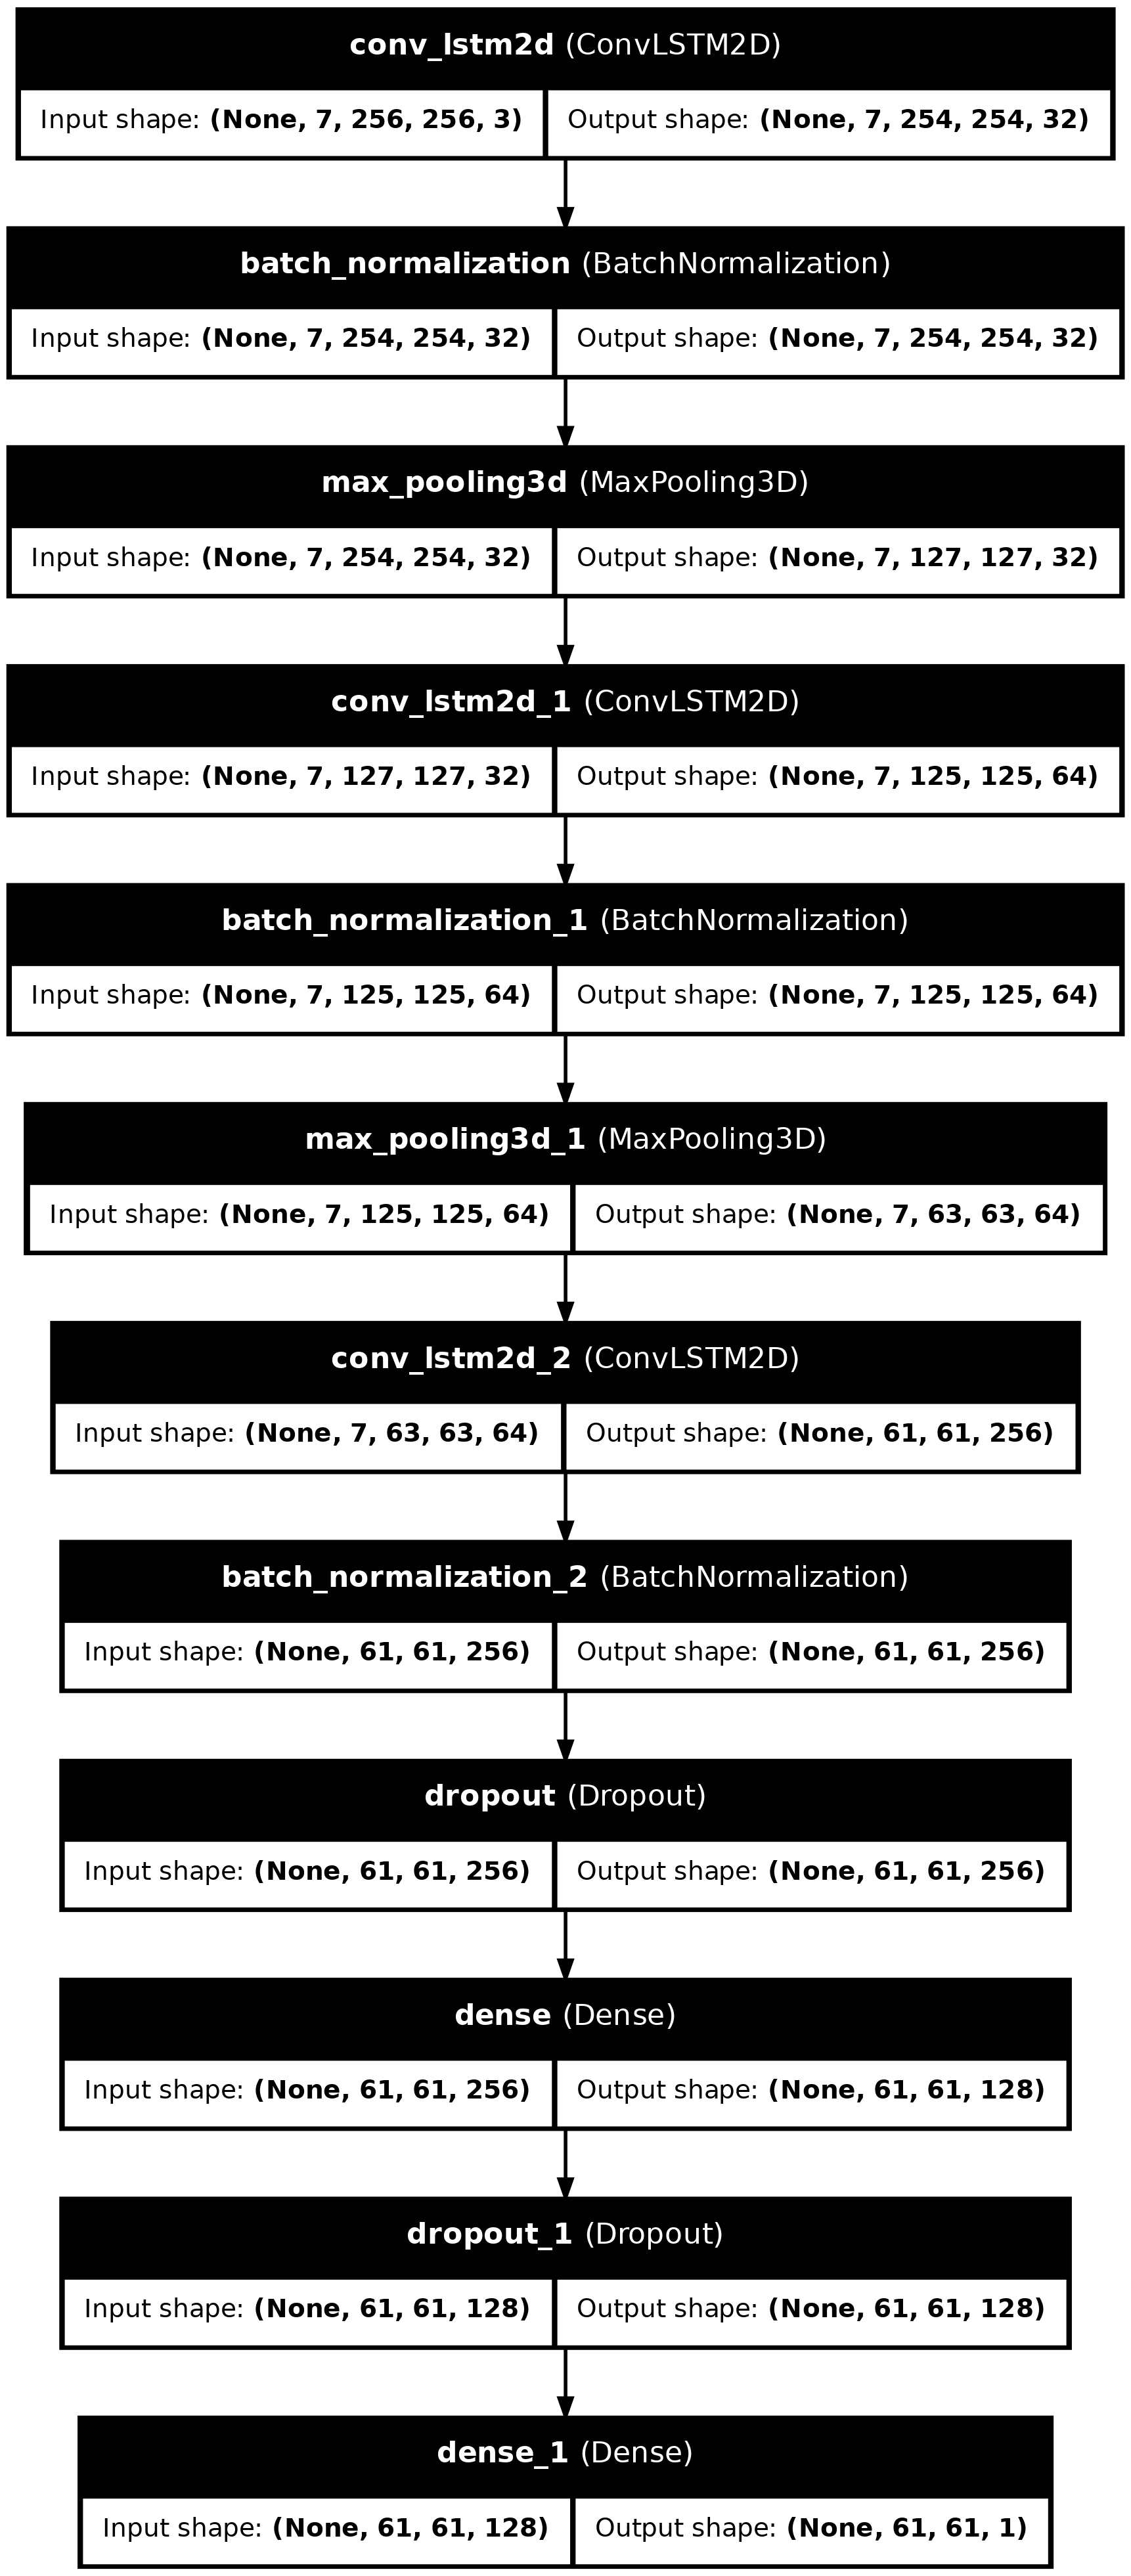

In [ ]:
# Plot the structure of the constructed model.
plot_model(convlstm_model, to_file = 'convlstm_model_structure_plot.png', show_shapes = True, show_layer_names = True)

# **Step 4.2: Compile & Train the Model**

Next, we will add an early stopping callback to prevent `overfitting` and start the training after compiling the model.

In [ ]:
# Create an Instance of Early Stopping Callback
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

# Compile the model and specify loss function, optimizer and metrics values to the model
convlstm_model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# Start training the model
convlstm_model_training_history = convlstm_model.fit(x = features_train, y = labels_train, epochs = 50, batch_size = 2 , shuffle = True, validation_split = 0.1, callbacks = [early_stopping_callback])


Epoch 1/50


2025-10-10 20:56:53.500029: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fbb2c4eca90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-10 20:56:53.500454: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2025-10-10 20:56:54.309988: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-10 20:57:00.972322: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=3,k4=2,k5=3,k6=3,k7=2} for conv (f16[2,61,61,128]{3,2,1,0}, u8[0]{0}) custom-call(f16[2,61,61,128]{3,2,1,0}, f16[128,3,3,128]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn

438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.7479 - loss: 3.8555

2025-10-10 21:02:13.258691: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=3,k4=2,k5=3,k6=3,k7=2} for conv (f16[1,61,61,128]{3,2,1,0}, u8[0]{0}) custom-call(f16[1,61,61,128]{3,2,1,0}, f16[128,3,3,128]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-10 21:02:13.258740: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=0,k4=1,k5=3,k6=3,k7=2} for conv (f16[1,61,61,128]{3,2,1,0}, u8[0]{0}) custom-call(f16[1,61,61,128]{3,2,1,0}, f16[128,3,3,128]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target=

439/439 ━━━━━━━━━━━━━━━━━━━━ 380s 741ms/step - accuracy: 0.7446 - loss: 4.0862 - val_accuracy: 0.7653 - val_loss: 3.7828
Epoch 2/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 284s 648ms/step - accuracy: 0.7469 - loss: 4.0801 - val_accuracy: 0.7653 - val_loss: 3.7828
Epoch 3/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 285s 650ms/step - accuracy: 0.7469 - loss: 4.0801 - val_accuracy: 0.7653 - val_loss: 3.7828
Epoch 4/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 285s 650ms/step - accuracy: 0.7469 - loss: 4.0801 - val_accuracy: 0.7653 - val_loss: 3.7828
Epoch 5/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 285s 650ms/step - accuracy: 0.7469 - loss: 4.0801 - val_accuracy: 0.7653 - val_loss: 3.7828
Epoch 6/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 285s 650ms/step - accuracy: 0.7469 - loss: 4.0801 - val_accuracy: 0.7653 - val_loss: 3.7828
Epoch 7/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 285s 650ms/step - accuracy: 0.7469 - loss: 4.0801 - val_accuracy: 0.7653 - val_loss: 3.7828
Epoch 8/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 285s 650ms/step - accuracy: 0.7469 - loss: 4.08

# **Evaluate the Trained Model**
After training, we will evaluate the model on the test set.

In [ ]:
# Evaluate the trained model.
model_evaluation_history = convlstm_model.evaluate(features_test, labels_test)

2025-04-14 20:38:45.933200: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k2=4,k4=1,k5=4,k6=3,k7=2} for conv %cudnn-conv.60 = (f16[32,126,126,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,126,126,64]{3,2,1,0} %bitcast.2851, f16[64,3,3,64]{3,2,1,0} %bitcast.2752), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2D" op_name="sequential_1/conv_lstm2d_1/while/conv_lstm_cell_1/convolution_7" source_file="/mnt/h/Study/Academic/Part 4/Project/.venv/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-04-14 20:38:48.187332: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc

1/2 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step - accuracy: 0.2188 - loss: 12.5923

2025-04-14 20:39:15.367843: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k2=4,k4=1,k5=4,k6=3,k7=2} for conv %cudnn-conv.60 = (f16[16,126,126,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[16,126,126,64]{3,2,1,0} %bitcast.2851, f16[64,3,3,64]{3,2,1,0} %bitcast.2752), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2D" op_name="sequential_1/conv_lstm2d_1/while/conv_lstm_cell_1/convolution_7" source_file="/mnt/h/Study/Academic/Part 4/Project/.venv/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-04-14 20:39:16.639236: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc

2/2 ━━━━━━━━━━━━━━━━━━━━ 47s 17s/step - accuracy: 0.2257 - loss: 12.4803


# **Save the Model**
Now, we will save the model to avoid training it from scratch every time we need the model.

In [ ]:
# Get the loss and accuracy from model_evaluation_history.
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

# Define the string date format.
# Get the current Date and Time in a DateTime Object.
# Convert the DateTime object to string according to the style mentioned in date_time format string.
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)

# Define a useful name for our model to make it easy for us while navigating through multiple saved models.
model_file_name = f'convlstm_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.keras'

# Save the Model.
convlstm_model.save(model_file_name)

### Load the saved Model

In [ ]:
convlstm_model = tf.keras.models.load_model('convlstm_model___Date_Time_2025_03_25__23_43_26___Loss_0.5146016478538513___Accuracy_0.8333333134651184.keras')

# **Step 4.3: Plot Model's Loss & Accuracy Curves**
Now, we will create a function `plot_metric()` to visualize the training and validation metrics. We already have separate metrics from our training and validation steps so now we just have to visualize them.

In [ ]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):

  '''
  This function will plot the metrics passed to it in a graph.

  Args:

    model_training_history: A history object containing a record of training and validation loss values and metrics values at successive epochs.
    metric_name_1:          The name of the first metric that needs to be plotted in the graph.
    metric_name_2:          The name of the second metric that needs to be plotted in the graph.
    plot_name:              The title of the graph.

  '''

  # Get metric values using metric names as identifiers.
  metric_value_1 = model_training_history.history[metric_name_1]
  metric_value_2 = model_training_history.history[metric_name_2]

  # Construct a range object which will be used as x-axis (horizontal plane) of the graph.
  epochs = range(len(metric_value_1))

  # Plot the graph
  plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
  plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)

  # Add title to the plot
  plt.title(str(plot_name))

  # Add legend to the plot.
  plt.legend()

Now we will utilize the function `plot_metric()` created above, to visualize and understand the metrics.

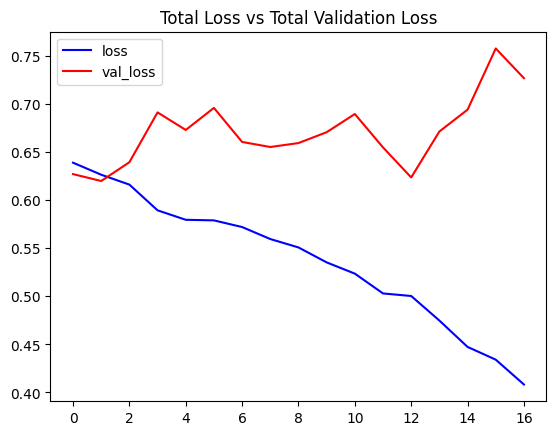

In [ ]:
# Visualize the training and validation loss metrics.
plot_metric(convlstm_model_training_history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')

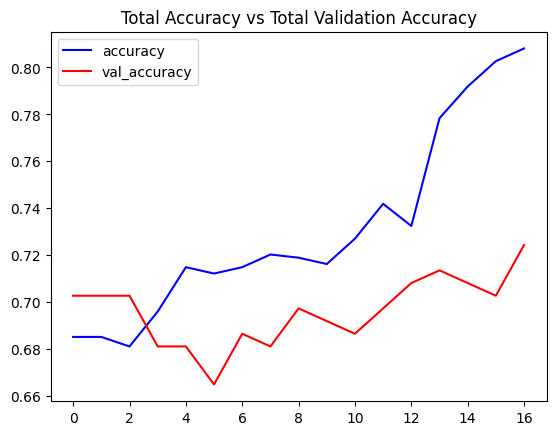

In [ ]:
# Visualize the training and validation accuracy metrics.
plot_metric(convlstm_model_training_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

# **Step 5: Implement The LRCN Approach**

In this step, we will implement the LRCN approach by combining Convolution and LSTM layers in a single model. Another similar approach can be to use a CNN model and LSTM model trained separately.

The CNN model can be used to extract spatial features from the frames in the video, and for this purpose, a pre-trained model can be used, that can be fine-tuned for the problem. And the LSTM model can then use the features extracted by CNN, to predict the action being performed in the video.

But here, we will implement another approach known as the `Long-term Recurrent Convolutional Network (LRCN)`, which combines CNN and LSTM layers in a single model. The Convolutional layers are used for spatial features extraction from the frames, and the extracted spatial features are fed to LSTM layes at each time-steps for temporal sequence modeling. This way the network learns spatiotemporal features directly in an end-to-end training, resulting in a robust model.





# **Step 5.1: Construct the Model**

To implement our LRCN architecture, we will use time-distributed `Conv2D` layers which will be followed by `MaxPooling2D` and `Dropout` layers. The feature extracted from the `Conv2D` layers will be then flattened using the `Flatten` layer and will be fed to a `LSTM` layer. The `Dense` layer with `softmax` activation will then use the output from the `LSTM` layer to predict the action being performed.

In [12]:
def create_LRCN_model():
  '''
  This function will construct the required LRCN model.

  Returns:
    model: It is the required constructed LRCN model.

  '''

  # We will use a Sequencial model for model construction.
  model = Sequential()

  # Define the Model Architecture.

  model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same',activation = 'relu'), input_shape = (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

  model.add(TimeDistributed(MaxPooling2D((4, 4))))
  model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same',activation = 'relu')))
  model.add(TimeDistributed(MaxPooling2D((4, 4))))
  model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same',activation = 'relu')))
  model.add(TimeDistributed(MaxPooling2D((2, 2))))
  model.add(TimeDistributed(Dropout(0.25)))
  
  model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same',activation = 'relu')))
  model.add(TimeDistributed(MaxPooling2D((2, 2))))
  model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Conv2D(128, (3, 3), padding='same',activation = 'relu')))
  model.add(TimeDistributed(MaxPooling2D((2, 2))))
  #model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Flatten()))

  model.add(LSTM(32))

  # Use Bidirectional LSTM here instead of normal LSTM
  #smodel.add(Bidirectional(LSTM(32)))

  model.add(Dense(len(CLASSES_LIST), activation = "softmax"))

  # Display the models summary.
  model.summary()

  # Return the constructed LRCN model.
  return model

Now we will utilize the function `create_LRCN_model()` created above to construct the required LRCN model.

In [13]:
# Construct the required LRCN model
LRCN_model = create_LRCN_model()

# Display the success message.
print("Model Created Successfully!!")

/mnt/f/Study/Academic/Part 4/Project/Sentinel/TestWithWebCam/.venv/lib/python3.11/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1760682456.234154    6890 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:10:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 128, 128,   │           448 │
│ (TimeDistributed)               │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 32, 32, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 32, 32, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 32, 32, 32) │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 8, 8, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 8, 8, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 8, 8, 64)   │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 4, 4, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 10, 4, 4, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 10, 4, 4, 64)   │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 10, 2, 2, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 10, 2, 2, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 10, 2, 2, 128)  │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 10, 1, 1, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ (None, 10, 128)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 155,108 (605.89 KB)

 Trainable params: 155,108 (605.89 KB)

 Non-trainable params: 0 (0.00 B)

Model Created Successfully!!


# **Check Model's Structure**
Now we will use the `plot_model()` function to check the structure of the constructed `LRCN` model. As we had checked for the previous model.

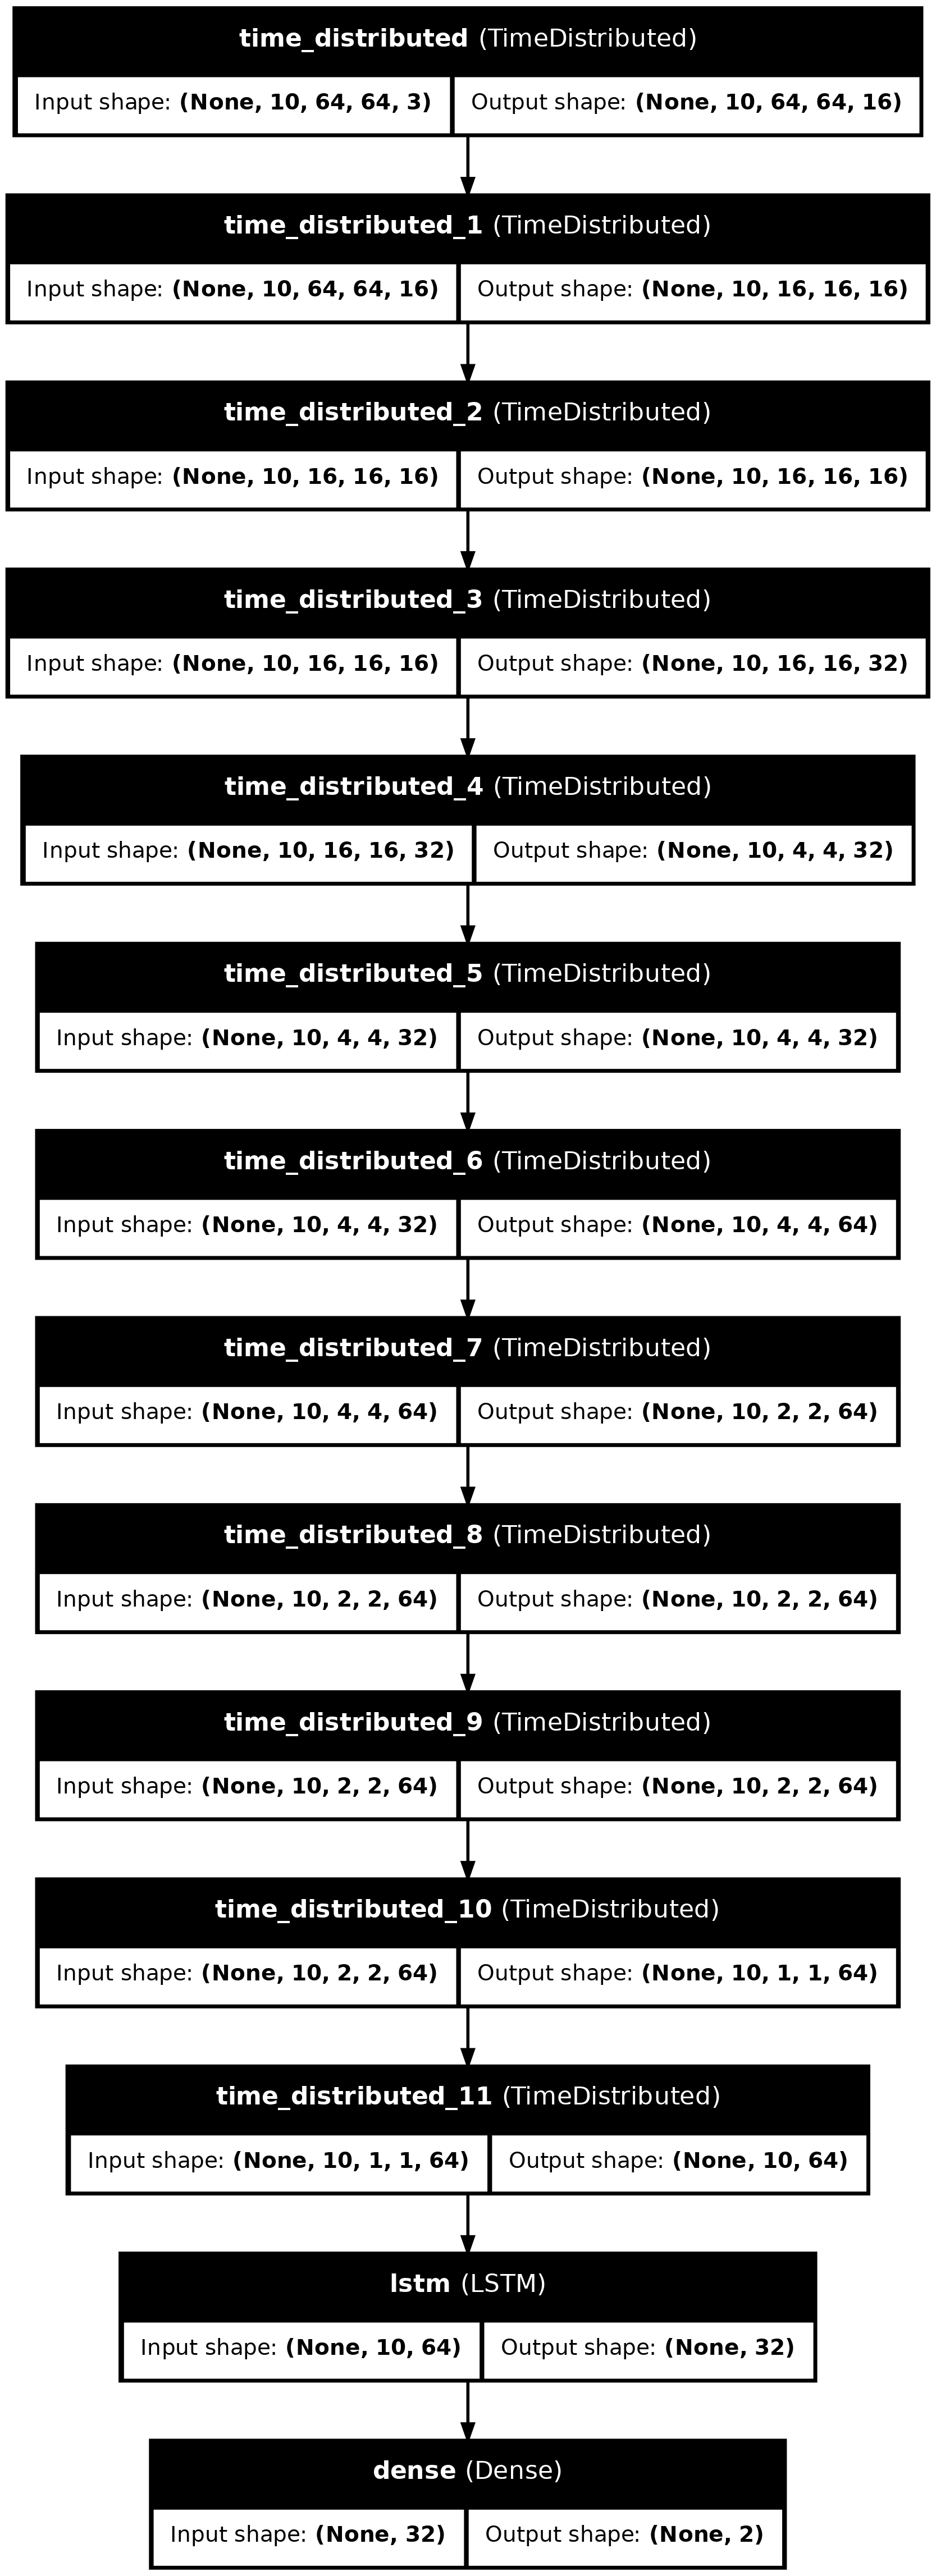

In [ ]:
# Plot the structure of the constructed LRCN model.
plot_model(LRCN_model, to_file = 'LRCN_model_structure_plot.png', show_shapes = True, show_layer_names = True)

# **Step 5.2: Compile & Train the Model**

After checking the structure, we will compile and start training the model.

In [ ]:
# Create an Instance of Early Stopping Callback.
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

# Compile the model and specify loss function, optimizer and metrics values to the model.
LRCN_model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# Start training the model.
LRCN_model_training_history = LRCN_model.fit(x = features_train, y = labels_train, epochs = 70, batch_size = 4, shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback])

Epoch 1/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.8201 - loss: 0.5534 - val_accuracy: 0.5000 - val_loss: 0.7158
Epoch 2/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8380 - loss: 0.4730 - val_accuracy: 0.7500 - val_loss: 0.3860
Epoch 3/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8638 - loss: 0.4085 - val_accuracy: 0.7500 - val_loss: 0.6457
Epoch 4/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8638 - loss: 0.3915 - val_accuracy: 0.7500 - val_loss: 0.3746
Epoch 5/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8869 - loss: 0.3546 - val_accuracy: 0.7500 - val_loss: 0.6173
Epoch 6/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9075 - loss: 0.2902 - val_accuracy: 0.7500 - val_loss: 0.7302
Epoch 7/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.8715 - loss: 0.3289 - val_accuracy: 0.7500 - val_loss: 0.6273
Epoch 8/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.8689 - loss: 0.4134 - val_accuracy: 0.7500 - 

   Creating simplified model...
   ✅ Total parameters: 2,996,932

   Class weights: {0: np.float64(1.076086956521739), 1: np.float64(2.3951612903225805), 2: np.float64(1.3026315789473684), 3: np.float64(0.5303571428571429)}

Training Simplified LRCN


2025-10-17 19:16:37.575109: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1119879168 exceeds 10% of free system memory.


Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.3045 - loss: 2.0602
Epoch 1: val_accuracy improved from None to 0.41341, saving model to best_simplified_LRCN.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 54s 295ms/step - accuracy: 0.2879 - loss: 1.9164 - val_accuracy: 0.4134 - val_loss: 1.3528 - learning_rate: 0.0010
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.2751 - loss: 1.6831
Epoch 2: val_accuracy improved from 0.41341 to 0.48603, saving model to best_simplified_LRCN.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 17s 188ms/step - accuracy: 0.3034 - loss: 1.6458 - val_accuracy: 0.4860 - val_loss: 1.3543 - learning_rate: 0.0010
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.3220 - loss: 1.5538
Epoch 3: val_accuracy did not improve from 0.48603
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - accuracy: 0.3399 - loss: 1.5326 - val_accuracy: 0.2793 - val_loss: 1.5022 - learning_rate: 0.0010
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.3234

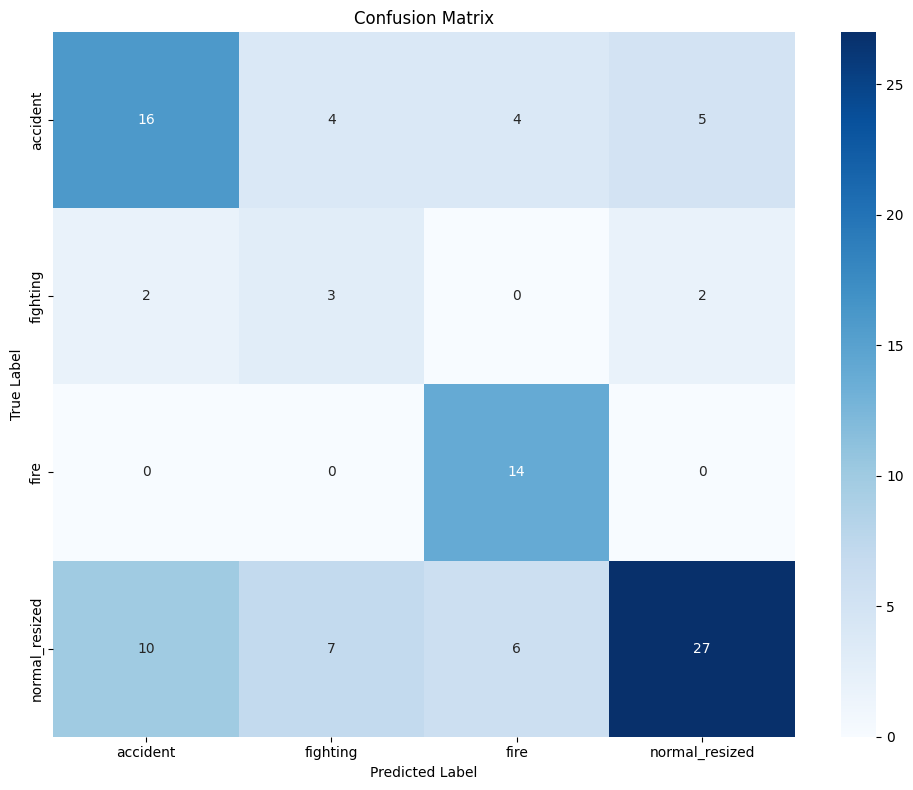


✅ Confusion matrix saved as 'confusion_matrix.png'
✅ Best model saved as 'best_simplified_LRCN.keras'


: 

In [ ]:
"""
Simplified LRCN Model - Optimized for Small Datasets
This version is more likely to succeed with 297 videos
"""

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, TimeDistributed, Dropout, LSTM, Dense, 
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import numpy as np

# ============================================================
# Simpler Model Architecture
# ============================================================

def create_simplified_LRCN():
    """
    Simplified LRCN optimized for small datasets:
    - MobileNetV2 (lighter than EfficientNetB0)
    - Single LSTM layer
    - Less aggressive dropout
    - Fewer dense layers
    """
    print("   Creating simplified model...")
    
    video_input = Input(shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3))
    
    # MobileNetV2 is more stable and requires less data
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
        alpha=1.0  # Full model size
    )
    
    # Freeze base model
    base_model.trainable = False
    
    # Feature extraction
    x = TimeDistributed(base_model)(video_input)
    x = TimeDistributed(GlobalAveragePooling2D())(x)
    x = TimeDistributed(Dropout(0.2))(x)  # Light dropout
    
    # Temporal modeling - Single LSTM is often enough
    x = LSTM(128, return_sequences=False, 
             dropout=0.3, recurrent_dropout=0.2)(x)
    
    # Classification head - Simpler
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(len(CLASSES_LIST), activation='softmax')(x)
    
    model = Model(inputs=video_input, outputs=outputs)
    
    return model, base_model

# Create model
LRCN_model, base_model = create_simplified_LRCN()
print(f"   ✅ Total parameters: {LRCN_model.count_params():,}")

# ============================================================
# Calculate Class Weights (Important for Imbalanced Data)
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

# Get class indices from one-hot labels
train_class_indices = np.argmax(labels_train_aug, axis=1)

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_class_indices),
    y=train_class_indices
)

class_weights = dict(enumerate(class_weights_array))
print(f"\n   Class weights: {class_weights}")

# ============================================================
# Training Configuration
# ============================================================

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=15,  # More patience for small datasets
    mode='max',
    restore_best_weights=True,
    verbose=1,
    min_delta=0.005
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    mode='min',
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_simplified_LRCN.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Higher initial learning rate for frozen base
optimizer = Adam(learning_rate=0.001)

LRCN_model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# ============================================================
# Training
# ============================================================

print("\n" + "="*60)
print("Training Simplified LRCN")
print("="*60)

history = LRCN_model.fit(
    x=features_train_aug,
    y=labels_train_aug,
    epochs=50,
    batch_size=8,  # Larger batch size for stability
    shuffle=True,
    validation_split=0.2,
    class_weight=class_weights,  # IMPORTANT: Handle imbalance
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

# ============================================================
# Evaluation
# ============================================================

print("\n" + "="*60)
print("Evaluation")
print("="*60)

# Load best model
LRCN_model = tf.keras.models.load_model('best_simplified_LRCN.keras')

# Evaluate
test_loss, test_accuracy = LRCN_model.evaluate(features_test, labels_test, verbose=1)

print(f"\n📊 RESULTS:")
print(f"   Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Best Val Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

# ============================================================
# If still not good, try fine-tuning
# ============================================================

if test_accuracy < 0.70:
    print("\n" + "="*60)
    print("Performance Below 70% - Attempting Fine-Tuning")
    print("="*60)
    
    # Unfreeze last 20 layers
    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    
    print(f"   Unfrozen {len([l for l in base_model.layers if l.trainable])} layers")
    
    # Recompile with lower learning rate
    optimizer_ft = Adam(learning_rate=0.00001)
    LRCN_model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizer_ft,
        metrics=['accuracy']
    )
    
    # Fine-tune
    history_ft = LRCN_model.fit(
        x=features_train_aug,
        y=labels_train_aug,
        epochs=30,
        batch_size=8,
        shuffle=True,
        validation_split=0.2,
        class_weight=class_weights,
        callbacks=[early_stopping, reduce_lr, checkpoint],
        verbose=1
    )
    
    # Re-evaluate
    test_loss, test_accuracy = LRCN_model.evaluate(features_test, labels_test, verbose=1)
    print(f"\n📊 AFTER FINE-TUNING:")
    print(f"   Test Accuracy: {test_accuracy*100:.2f}%")
    print(f"   Test Loss: {test_loss:.4f}")

# ============================================================
# Confusion Matrix and Per-Class Accuracy
# ============================================================

print("\n" + "="*60)
print("Detailed Performance Analysis")
print("="*60)

from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_pred = LRCN_model.predict(features_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(labels_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

print("\nConfusion Matrix:")
print(cm)

print("\nPer-Class Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=CLASSES_LIST,
    zero_division=0
))

# Visualize confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES_LIST,
            yticklabels=CLASSES_LIST)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix saved as 'confusion_matrix.png'")
print("✅ Best model saved as 'best_simplified_LRCN.keras'")

# **Evaluating the Trained Model**

As done for previous one, we will evaluate the `LRCN` model on the test set.

In [20]:
# Evaluate the trained model.
model_evaluation_history = LRCN_model.evaluate(features_test, labels_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy: 0.6600 - loss: 1.6876 - top_k_accuracy_float32: 0.9000


# **Save the Model**
After that, we will save the model for future uses using the same technique we had used for previous model.

In [ ]:
# Get the loss and accuracy from mode_evaluation_history.
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

# Define the string date format.
# Get the current Date and Time in a DateTime Object.
# Convert the DateTime object to string according to the style mentioned in date_time_format string.
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)

# Define a useful name for our model to make it easy for us while navigating through multiple saved models.
model_file_name = f'multiclass_LRCN_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.keras'

# Save the Model.
LRCN_model.save(model_file_name)


### Load the saved model

In [ ]:
LRCN_model = tf.keras.models.load_model('LRCN_model___Date_Time_2025_03_27__02_14_17___Loss_0.44080331921577454___Accuracy_0.7708333134651184.keras')

I0000 00:00:1743022550.473532     739 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:10:00.0, compute capability: 7.5


# **Step 5.3: Plot Model's Loss & Accuracy Curves**

Now we will utilize the function `plot_metric()` we had created above to visualize the training and validation metrics of this model.

In [ ]:
# Visualize the training and validation loss matrices.
plot_metric(LRCN_model_training_history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')

NameError: name 'plot_metric' is not defined

In [ ]:
# Visualize the training and validation accuracy metrices.
plot_metric(LRCN_model_training_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

NameError: name 'plot_metric' is not defined

# **Step 6: Test the Best Performing Model on YouTube videos**

# **Create a Function to Download YouTube Videos**

We will create a function `download_youtube_videos()` to download the YouTube videos first using `pafy` library. The library only requires a URL to a video to download it along with its associated metadata like the title of the video.

In [ ]:
pafy.set_backend("yt_dlp")
def download_youtube_videos(youtube_video_url, output_directory):
    """
    This function downloads the YouTube video whose URL is passed to it as an argument.

    Args:
        youtube_video_url: URL of the video that is required to be downloaded.
        output_directory: The directory path to which the video needs to be stored after downloading.

    Returns:
        title: The title of the downloaded YouTube video.
    """

    # Create a video object which contains useful information about the video.
    video = pafy.new(youtube_video_url)

    # Retrieve the title of the video.
    title = video.title

    # Get the best available quality object for the video.
    video_best = video.getbest()

    # Construct the output file path.
    output_file_path = f'{output_directory}/{title}.mp4'

    # Download the YouTube video at the best available quality and store it to the constructed path.
    video_best.download(filepath=output_file_path, quiet=True)

    # Return the video title.
    return title


AttributeError: module 'pafy' has no attribute 'set_backend'

# **Download a Test Video**

Now we will utilize the function `download_youtube_videos()` created above to download a youtube video on which the LRCN model will be tested.

In [ ]:
# Make the Output directory if it does not exist
test_videos_directory = 'test_videos'
os.makedirs(test_videos_directory, exist_ok = True)

# Download a YouTube Video.
#video_title = download_youtube_videos('https://www.youtube.com/watch?v=mzelalrFNRk', test_videos_directory)
video_title = "test_video_1"

# Get the YouTube Video's path we just downloaded.
input_video_file_path = f'{test_videos_directory}/{video_title}.mp4'

# **Download The Model**

In [ ]:
from google.colab import files

# Download the file
#files.download("convlstm_model___Date_Time_2025_01_18__17_14_01___Loss_0.2780801057815552___Accuracy_0.9027777910232544.keras")
files.download("LRCN_model___Date_Time_2025_01_18__18_17_00___Loss_0.28902676701545715___Accuracy_0.8819444179534912.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Create a Function to perform Action Recognition on Videos**

Next, we will create a function `predict_on_video()` that will simply read a video frame by frame from the path passed in as an argument and will perform action recognition on video and save the results.

In [7]:
def predict_on_video(video_file_path, output_file_path, SEQUENCE_LENGTH, Loaded_Model):
    """
    This function will perform action recognition on a video using the LRCN model.
    Args:
        video_file_path: The path of the video file in the disk which action recognition is to be performed.
        output_file_path: The file where the corresponding prediction for the actions performed on each frame will be stored.
        SEQUENCE_LENGTH: Fixed number of frames in a video that can be fed to the model as one sequence.
    """

    # Initialize the VideoCapture object to read from the video file.
    video_reader = cv.VideoCapture(video_file_path)

    # Get the width and height of the video.
    original_width = int(video_reader.get(cv.CAP_PROP_FRAME_WIDTH))
    original_height = int(video_reader.get(cv.CAP_PROP_FRAME_HEIGHT))

    # Initialize the VideoWriter object to store the output video in the disk.
    video_writer = cv.VideoWriter(output_file_path, cv.VideoWriter_fourcc('M', 'P', '4', 'V'), video_reader.get(cv.CAP_PROP_FPS), (original_width, original_height))

    # Declare a queue to store video frames.
    frames_queue = deque(maxlen = SEQUENCE_LENGTH)

    # Define a queue to store video frames
    frames_queue = deque(maxlen=SEQUENCE_LENGTH)

    # Initialize a variable to store the predicted action being performed in the video.
    predicted_class_name = ''

    while video_reader.isOpened():

      # Read the frame.
      ok, frame = video_reader.read()

      # Check if frame is not read properly then break the loop
      if not ok:
        break

      # Resize the Frame to fixed Dimensions.
      resized_frame = cv.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

      # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1.
      normalized_frame = resized_frame / 255

      # Appending the pre-processed frame into the frames list.
      frames_queue.append(normalized_frame)

      # Check if the number of frame in the queue are equal to the fixed sequence length.
      if len(frames_queue) == SEQUENCE_LENGTH:

        # Pass the normalized frames to the model and get the predicted probabilities.
        predicted_label_probabilities = Loaded_Model.predict(np.expand_dims(frames_queue, axis = 0))[0]

        # Get the index of class with highest probability.
        predicted_label = np.argmax(predicted_label_probabilities)

        # Get the class name using the retrieved index.
        predicted_class_name = CLASSES_LIST[predicted_label]
        
        if predicted_class_name == "accident":
          cv.putText(frame, "Abnormal Activity [ Accident ]", (10, 30), cv.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
        
        elif predicted_class_name == "fighting":
          cv.putText(frame, "Abnormal Activity [ Fighting ]", (10, 30), cv.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

        elif predicted_class_name == "fire":
          cv.putText(frame, "Abnormal Activity [ Fire ]", (10, 30), cv.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
        
        else:
          cv.putText(frame, "Normal Activity", (10, 30), cv.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)

      # Write predicted class name on top of the Frame.
      #cv.putText(frame, predicted_class_name, (10, 30), cv.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

      # Write The frame into the disk using the VideoWriter Object.
      video_writer.write(frame)

    # Release the VideoCapture and VideoWriter objects.
    video_reader.release()
    video_writer.release()

# **Perform Action Recognition on the Test Video**

Now we will utilize the function `predict_on_video()` created above to perform action recognition on the test video we had downloaded using the function `download_youtube_videos()` and display the ouput video with the predicted action overlayed on it.

In [ ]:
test_videos_directory = 'test/outputs--multiclass_LRCN_model___Date_Time_2025_03_27__17_30_45___Loss_0.6180427074432373___Accuracy_0.8125'
input_videos_directory = 'test/inputs'

Loaded_Model = tf.keras.models.load_model('models/multiclass_LRCN_model___Date_Time_2025_03_27__17_30_45___Loss_0.6180427074432373___Accuracy_0.8125.keras')

#Loaded_Model = LRCN_model
#Loaded_Model = convlstm_model

# Fetch all .mp4 videos in input folder
video_files = [f for f in os.listdir(input_videos_directory) if f.endswith('.mp4')]
video_files.sort()  # optional: to keep order consistent

for i, video_file in enumerate(video_files, start=1):
    video_title = os.path.splitext(video_file)[0]  # e.g., "test_1"
    print(f'Performing Prediction On Video {i}: {video_file}')

    input_video_file_path = os.path.join(input_videos_directory, video_file)
    output_video_path = os.path.join(
        test_videos_directory,
        f'{video_title}-Output-SeqLen{SEQUENCE_LENGTH}.mp4'
    )

    # Perform Action Recognition on the Test Video.
    predict_on_video(input_video_file_path, output_video_path, SEQUENCE_LENGTH, Loaded_Model)

    # Optionally display the output
    # VideoFileClip(output_video_path, audio=False, target_resolution=(300,None)).ipython_display()

I0000 00:00:1760987046.478886 2518025 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:10:00.0, compute capability: 7.5


Performing Prediction On Video 1: test_4.mp4


OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'
2025-10-21 01:04:08.676991: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━

# **Create a Function To Perform a Single Prediction on Videos**

Now let's create a function that will perform a single prediction for the complete videos. We will extract evenly distributed `N (SEQUENCE_LENGTH)` frames from the entire video and pass them to the LRCN model. This approach is really usefull when we are working with videos containing only one activity as it saves unnecessary computations and time in that scenario.

In [ ]:
def predict_single_action(video_file_path, SEQUENCE_LENGTH):
    """
    This function will perform single action recognition prediction on a video using the LRCN model.
    Args:
    video_file_path:  The path of the video stored in the disk on which the action recognition is to be performed.
    SEQUENCE_LENGTH:  The fixed number of frames of a video that can be passed to the model as one sequence.
    """

    # Initialize the VideoCapture object to read from the video file.
    video_reader = cv.VideoCapture(video_file_path)

    # Get the width and height of the video.
    original_video_width = int(video_reader.get(cv.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv.CAP_PROP_FRAME_HEIGHT))

    # Declare a list to store video frames we will extract.
    frames_list = []

    # Initialize a variable to store the predicted action being performed in the video.
    predicted_class_name = ''

    # Get the number of frames in the video.
    video_frames_count = int(video_reader.get(cv.CAP_PROP_FRAME_COUNT))

    # Calculate the interval after whice frames will be added to the list.
    skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH), 1)

    # Iterating the number of times equal to the fixed length of sequence.
    for frame_counter in range(SEQUENCE_LENGTH):

      # Set the current frame position of the video.
      video_reader.set(cv.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

      # Read a frame.
      success, frame = video_reader.read()

      # Check if frame is not read properly then break the loop
      if not success:
        break

      # Resize the Frame to fixed Dimensions.
      resized_frame = cv.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

      # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1.
      nomalized_frame = resized_frame / 255

      # Appending the pre-processed frame into the frame list
      frames_list.append(nomalized_frame)

    # Passing the pre-processed frames to the model and get the predicted probabilities.
    predicted_label_probabilities = LRCN_model.predict(np.expand_dims(frames_list, axis = 0))[0]

    # Get the index of class with highest probability.
    predicted_label = np.argmax(predicted_label_probabilities)

    # Get the class name using the retrieved index.
    predicted_class_name = CLASSES_LIST[predicted_label]

    # Display the predicted action along with the prediction confidence.
    print(f'Action Required: {predicted_class_name}\nConfidence: {predicted_label_probabilities[predicted_label]}')

    # Release the VideoCapture object.
    video_reader.release()

# **Perform Single Prediction on a Test Video**

Now we will utilize the function `predict_single_action()` created above to perform a single prediction on a complete youtube test video that we will download using the function `download_youtube_videos()` we had created above.

In [ ]:
# Video file name
video_title = 'test_video_3'

# Construct the input youtube video path
input_video_file_path = f'{test_videos_directory}/{video_title}.avi'

# Perform Single Prediction on the Test Video.
predict_single_action(input_video_file_path, SEQUENCE_LENGTH)

# Display the input video.
#VideoFileClip(input_video_file_path, audio=False, target_resolution=(300,None)).ipython_display()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Action Required: RopeClimbing
Confidence: 0.7695754766464233
